# Production Forecasting using Random Forest Regressor

## Project Overview

This notebook develops a machine learning model to forecast oil production using the Volve Field Production Dataset. The objective is to predict daily oil production based on operational parameters such as pressure, temperature, choke size, and production history.

### Objectives

- Perform comprehensive data preprocessing
- Conduct exploratory data analysis (EDA)
- Engineer meaningful features
- Train a Random Forest Regressor
- Evaluate forecasting performance
- Save the trained model for deployment in the integrated monitoring system

**Dataset:** Volve Production Data (Equinor)

**Algorithm:** Random Forest Regressor

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Model Saving
import joblib

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
# ==========================================
# Load Dataset
# ==========================================

file_path = "Volve production data.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Daily Production Data"
)

print("Dataset Loaded Successfully.\n")

print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully.

Dataset Shape: (15634, 24)


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,0.00000,0.0,0.000000,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,1.003059,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.979008,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.545759,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,277.27826,0.0,1.215987,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNUL

In [4]:
# ==========================================
# Dataset Information
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNUL

In [5]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
DATEPRD,15634,NaN,NaN,NaN,2012-11-07 17:39:58.004349,2007-09-01 00:00:00,2010-07-30 00:00:00,2013-05-08 00:00:00,2015-02-19 00:00:00,2016-12-01 00:00:00,NaN
WELL_BORE_CODE,15634,7,NO 15/9-F-4 AH,3327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_WELL_BORE_CODE,15634.0,NaN,NaN,NaN,5908.581745,5351.0,5599.0,5693.0,5769.0,7405.0,649.231622
NPD_WELL_BORE_NAME,15634,7,15/9-F-4,3327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_FIELD_CODE,15634.0,NaN,NaN,NaN,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,0.0
NPD_FIELD_NAME,15634,1,VOLVE,15634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPD_FACILITY_CODE,15634.0,NaN,NaN,NaN,369304.0,369304.0,369304.0,369304.0,369304.0,369304.0,0.0
NPD_FACILITY_NAME,15634,1,MÆRSK INSPIRER,15634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ON_STREAM_HRS,15349.0,NaN,NaN,NaN,19.994093,0.0,24.0,24.0,24.0,25.0,8.369978
AVG_DOWNHOLE_PRESSURE,8980.0,NaN,NaN,NaN,181.803869,0.0,0.0,232.896939,255.401455,397.58855,109.712363


In [6]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
BORE_WI_VOL,9928,63.50
AVG_ANNULUS_PRESS,7744,49.53
AVG_CHOKE_SIZE_P,6715,42.95
AVG_DOWNHOLE_PRESSURE,6654,42.56
AVG_DOWNHOLE_TEMPERATURE,6654,42.56
AVG_DP_TUBING,6654,42.56
AVG_WHT_P,6488,41.50
AVG_WHP_P,6479,41.44
AVG_CHOKE_UOM,6473,41.40
BORE_OIL_VOL,6473,41.40


In [7]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [8]:
# ==========================================
# Convert Date Column
# ==========================================

df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

print(df["DATEPRD"].head())

0   2014-04-07
1   2014-04-08
2   2014-04-09
3   2014-04-10
4   2014-04-11
Name: DATEPRD, dtype: datetime64[us]


In [9]:
# ==========================================
# Data Types
# ==========================================

dtype_df = pd.DataFrame(df.dtypes)

dtype_df.columns = ["Data Type"]

dtype_df

,Data Type
DATEPRD,datetime64[us]
WELL_BORE_CODE,str
NPD_WELL_BORE_CODE,int64
NPD_WELL_BORE_NAME,str
NPD_FIELD_CODE,int64
NPD_FIELD_NAME,str
NPD_FACILITY_CODE,int64
NPD_FACILITY_NAME,str
ON_STREAM_HRS,float64
AVG_DOWNHOLE_PRESSURE,float64


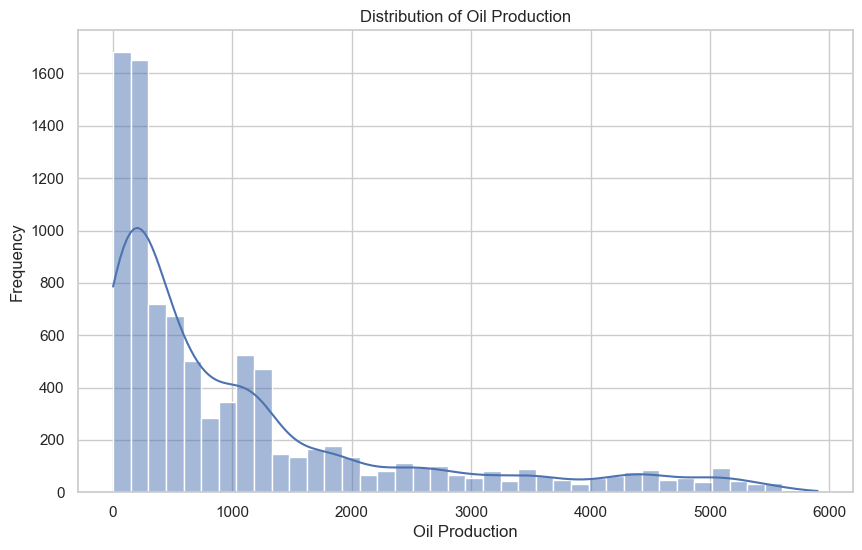

In [10]:
# ==========================================
# Distribution of Oil Production
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["BORE_OIL_VOL"],
    bins=40,
    kde=True
)

plt.title("Distribution of Oil Production")

plt.xlabel("Oil Production")

plt.ylabel("Frequency")

plt.show()

In [11]:
# ==========================================
# Separate Numerical and Categorical Columns
# ==========================================

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of Numerical Features : {len(numerical_cols)}")
print(f"Number of Categorical Features : {len(categorical_cols)}")

print("\nNumerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

Number of Numerical Features : 16
Number of Categorical Features : 7

Numerical Features:
['NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 'NPD_FACILITY_CODE', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL']

Categorical Features:
['WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_NAME', 'NPD_FACILITY_NAME', 'AVG_CHOKE_UOM', 'FLOW_KIND', 'WELL_TYPE']


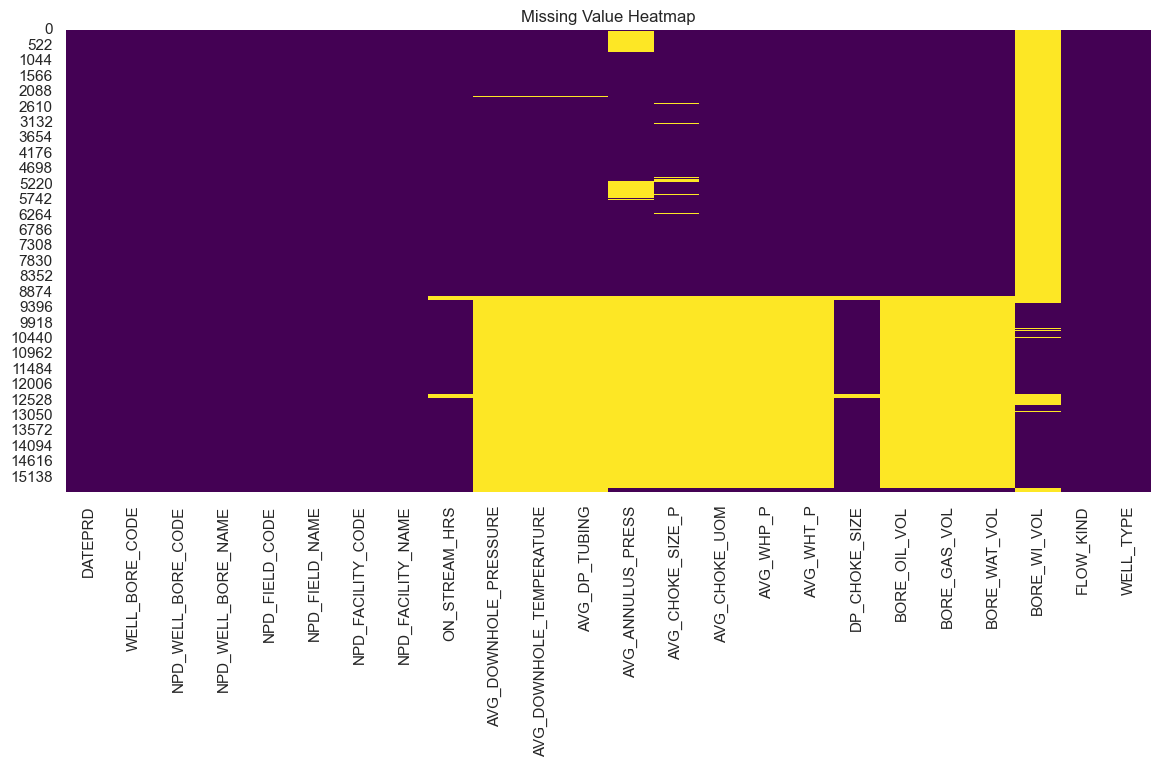

In [12]:
# ==========================================
# Missing Value Heatmap
# ==========================================

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

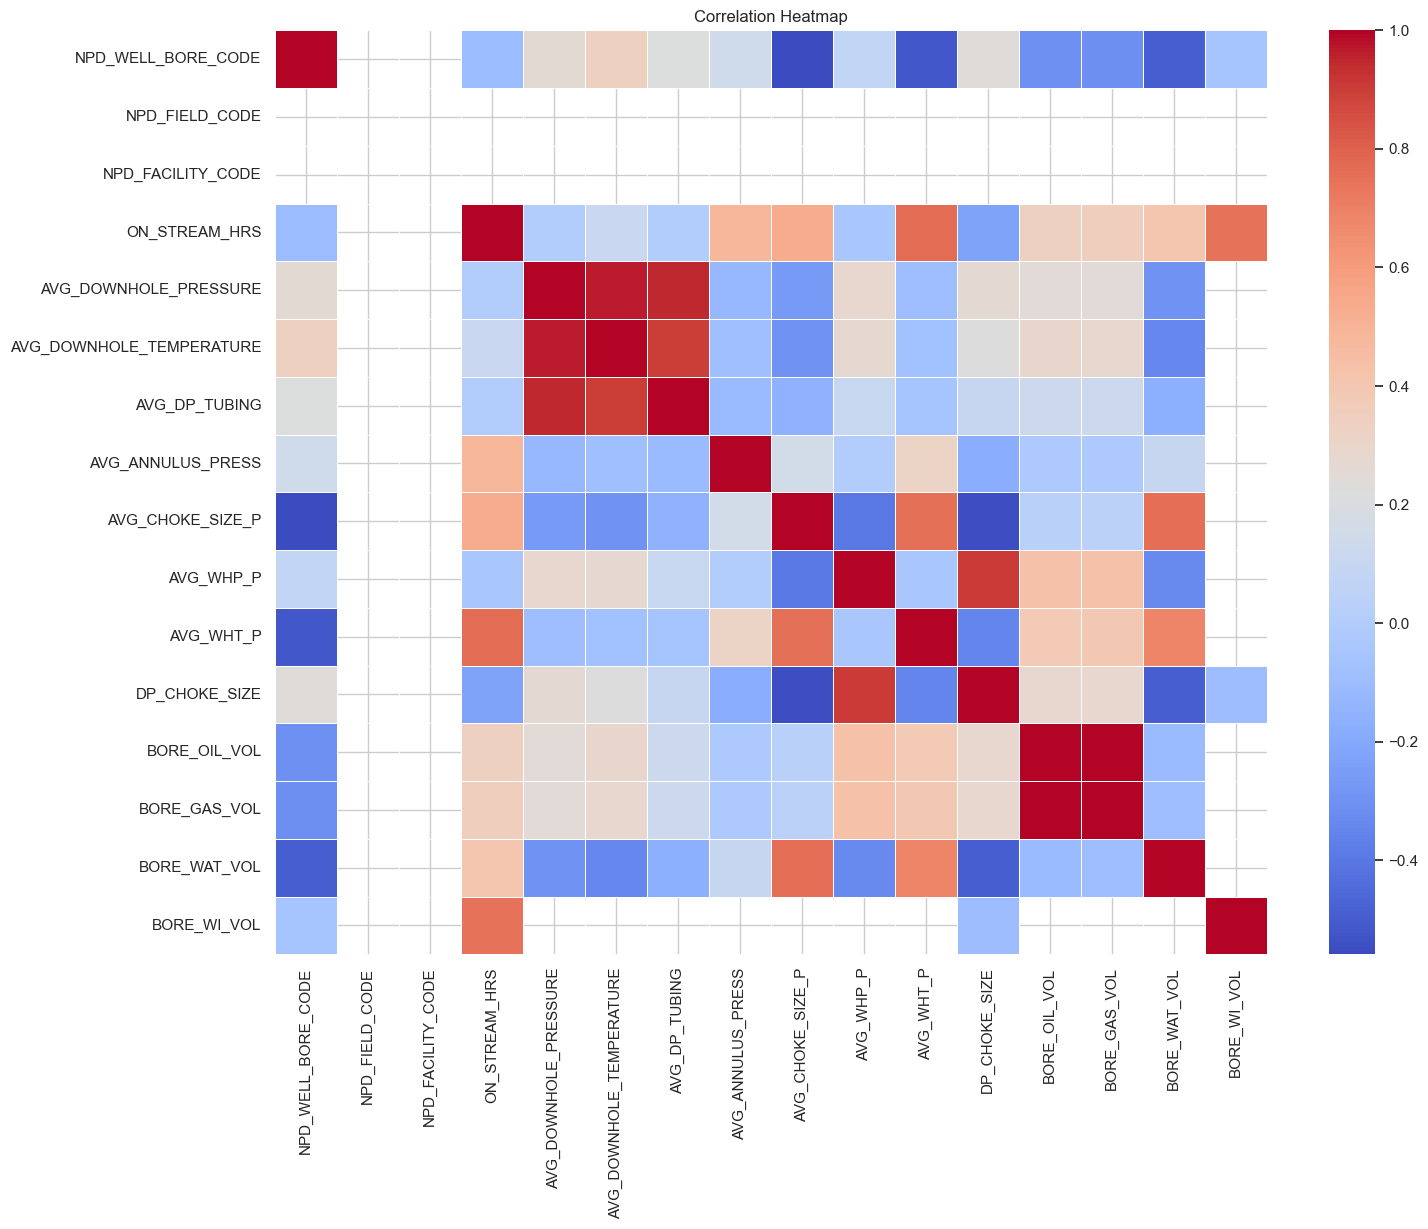

In [13]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(16,12))

corr_matrix = df[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

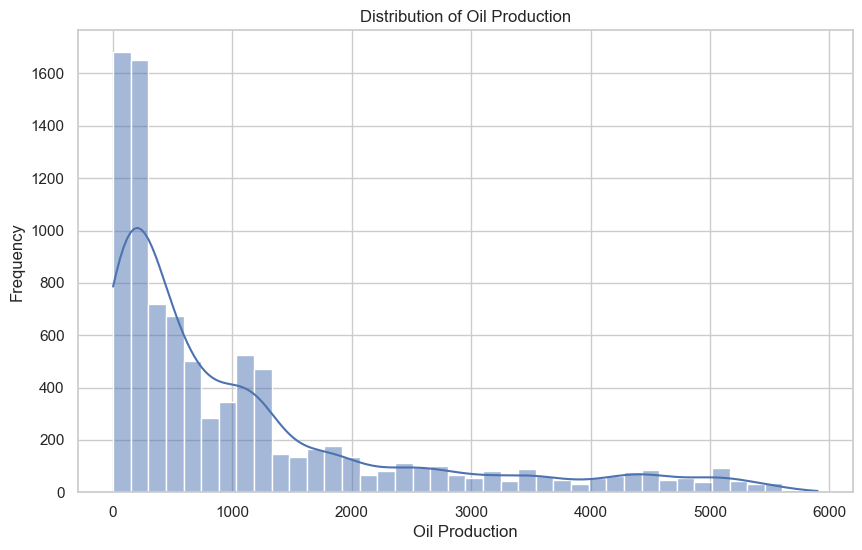

In [14]:
# ==========================================
# Oil Production Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["BORE_OIL_VOL"],
    bins=40,
    kde=True
)

plt.title("Distribution of Oil Production")

plt.xlabel("Oil Production")

plt.ylabel("Frequency")

plt.show()

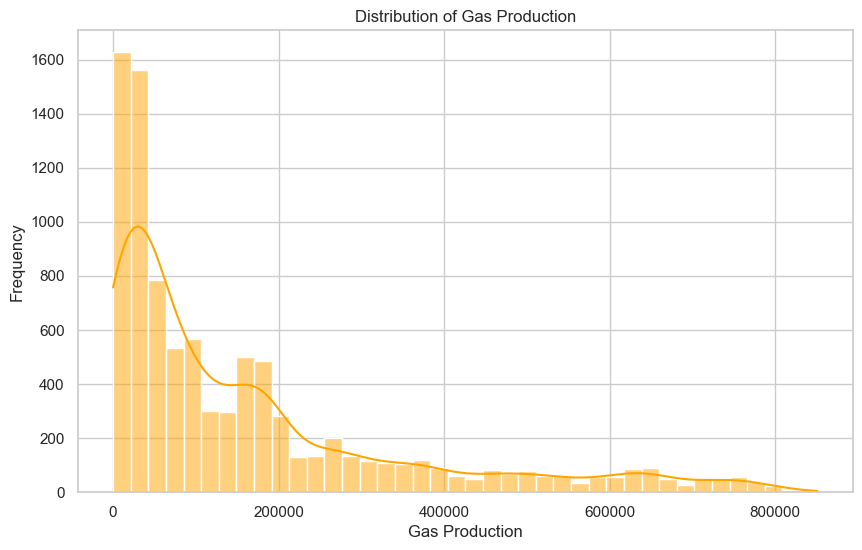

In [15]:
# ==========================================
# Gas Production Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["BORE_GAS_VOL"],
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Distribution of Gas Production")

plt.xlabel("Gas Production")

plt.ylabel("Frequency")

plt.show()

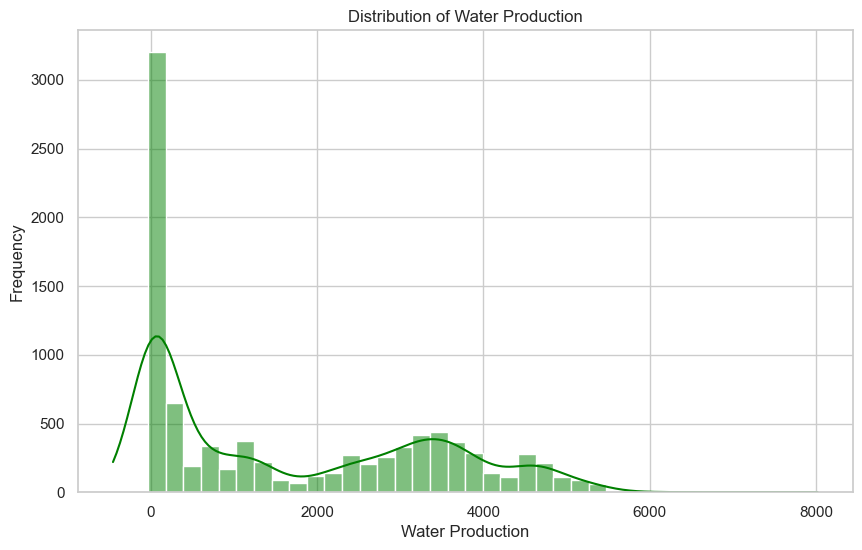

In [16]:
# ==========================================
# Water Production Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["BORE_WAT_VOL"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Distribution of Water Production")

plt.xlabel("Water Production")

plt.ylabel("Frequency")

plt.show()

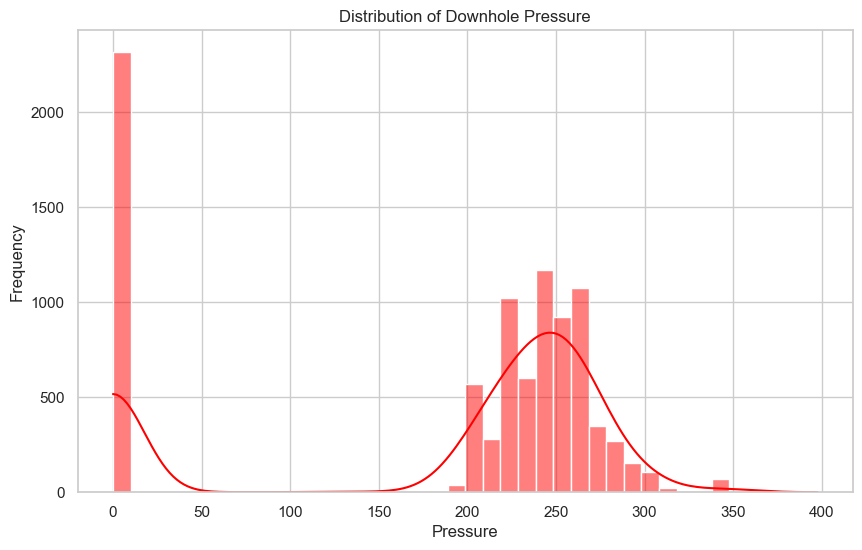

In [17]:
# ==========================================
# Downhole Pressure Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["AVG_DOWNHOLE_PRESSURE"],
    bins=40,
    kde=True,
    color="red"
)

plt.title("Distribution of Downhole Pressure")

plt.xlabel("Pressure")

plt.ylabel("Frequency")

plt.show()

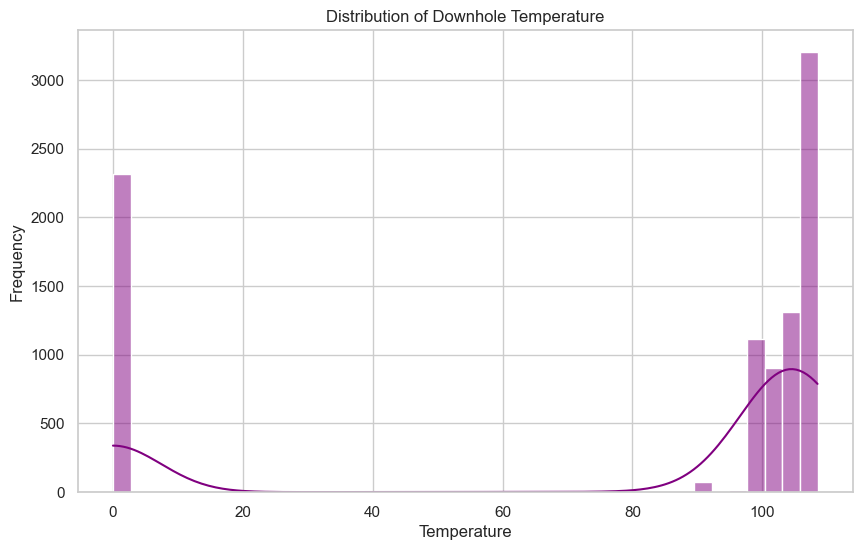

In [18]:
# ==========================================
# Downhole Temperature Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["AVG_DOWNHOLE_TEMPERATURE"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Distribution of Downhole Temperature")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

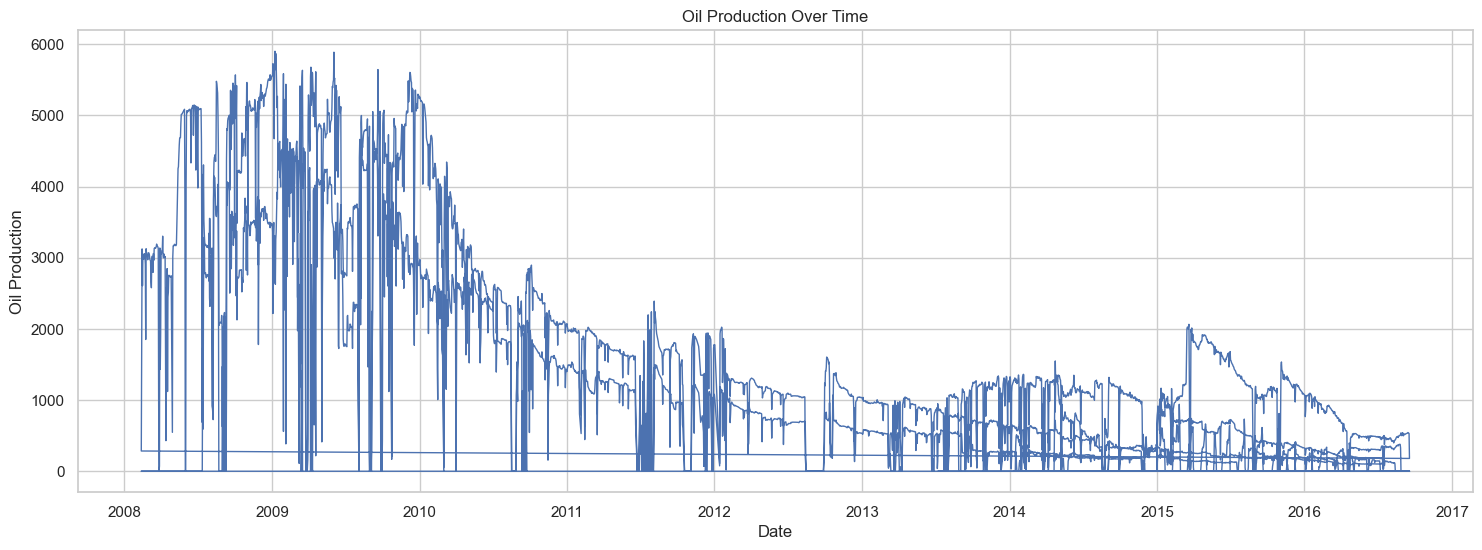

In [19]:
# ==========================================
# Oil Production Trend
# ==========================================

plt.figure(figsize=(18,6))

plt.plot(
    df["DATEPRD"],
    df["BORE_OIL_VOL"],
    linewidth=1
)

plt.title("Oil Production Over Time")

plt.xlabel("Date")

plt.ylabel("Oil Production")

plt.grid(True)

plt.show()

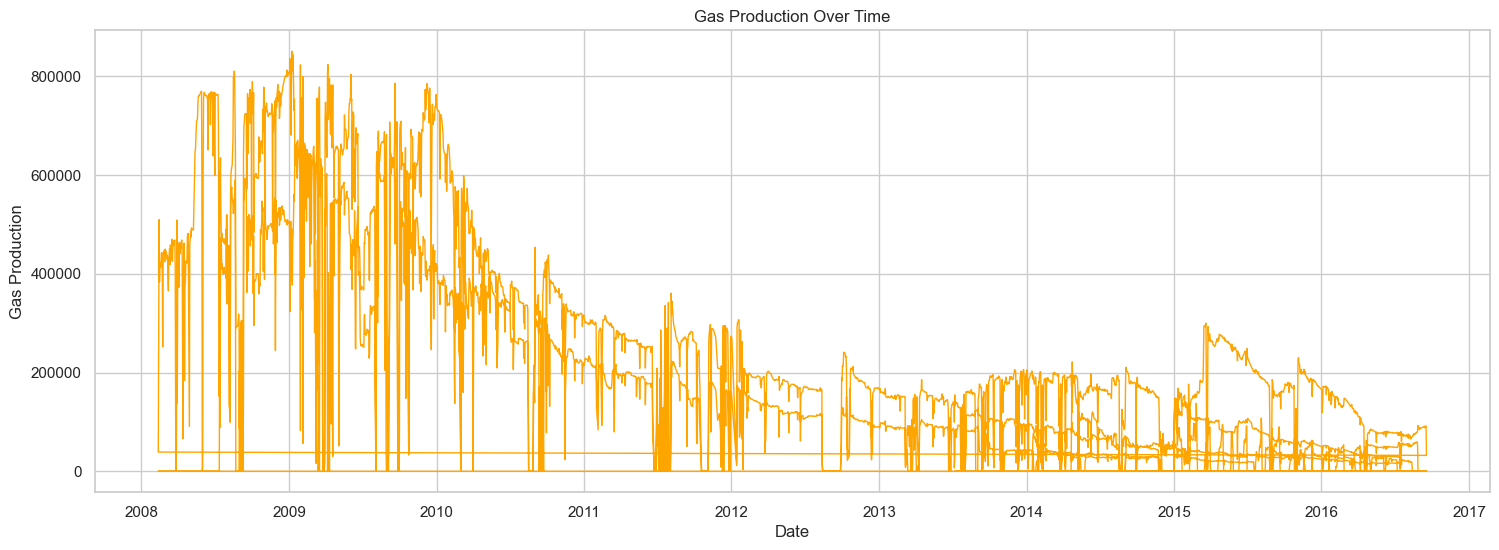

In [20]:
# ==========================================
# Gas Production Trend
# ==========================================

plt.figure(figsize=(18,6))

plt.plot(
    df["DATEPRD"],
    df["BORE_GAS_VOL"],
    linewidth=1,
    color="orange"
)

plt.title("Gas Production Over Time")

plt.xlabel("Date")

plt.ylabel("Gas Production")

plt.grid(True)

plt.show()

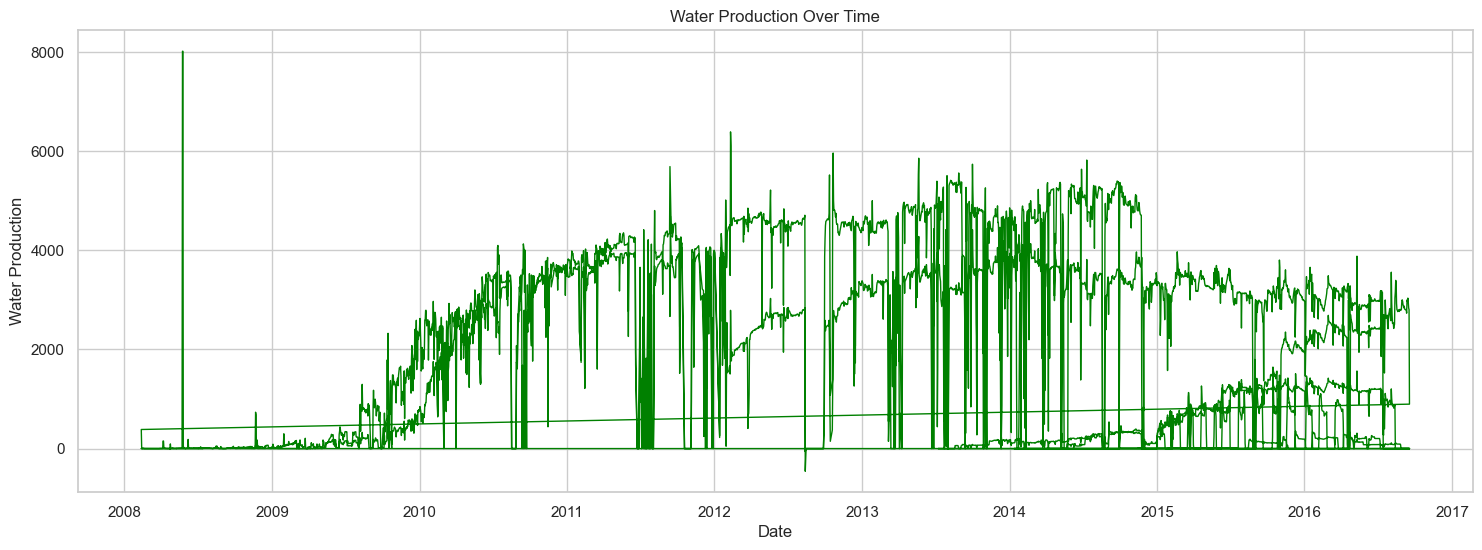

In [21]:
# ==========================================
# Water Production Trend
# ==========================================

plt.figure(figsize=(18,6))

plt.plot(
    df["DATEPRD"],
    df["BORE_WAT_VOL"],
    linewidth=1,
    color="green"
)

plt.title("Water Production Over Time")

plt.xlabel("Date")

plt.ylabel("Water Production")

plt.grid(True)

plt.show()

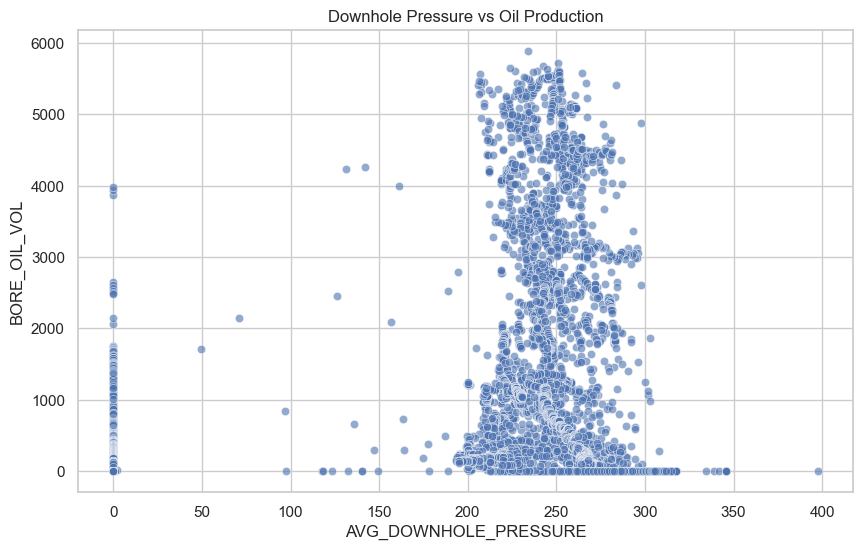

In [22]:
# ==========================================
# Pressure vs Oil Production
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="AVG_DOWNHOLE_PRESSURE",
    y="BORE_OIL_VOL",
    alpha=0.6
)

plt.title("Downhole Pressure vs Oil Production")

plt.show()

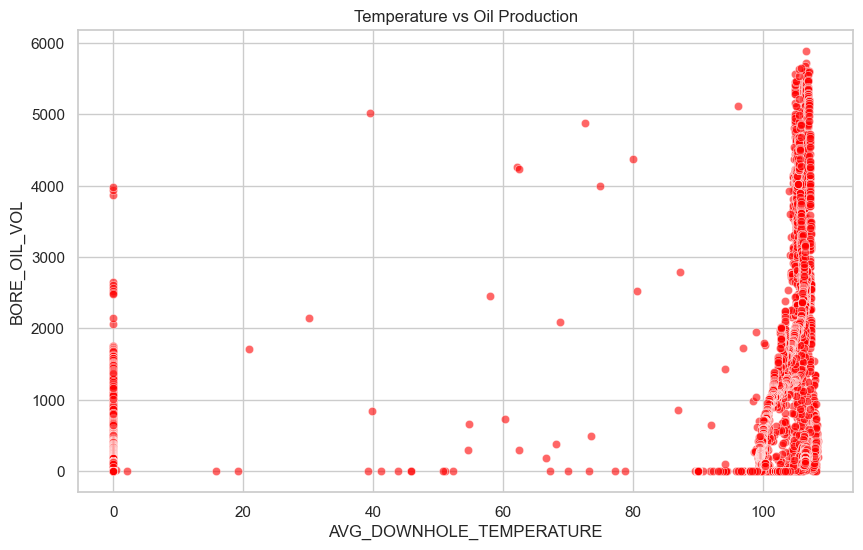

In [23]:
# ==========================================
# Temperature vs Oil Production
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="AVG_DOWNHOLE_TEMPERATURE",
    y="BORE_OIL_VOL",
    alpha=0.6,
    color="red"
)

plt.title("Temperature vs Oil Production")

plt.show()

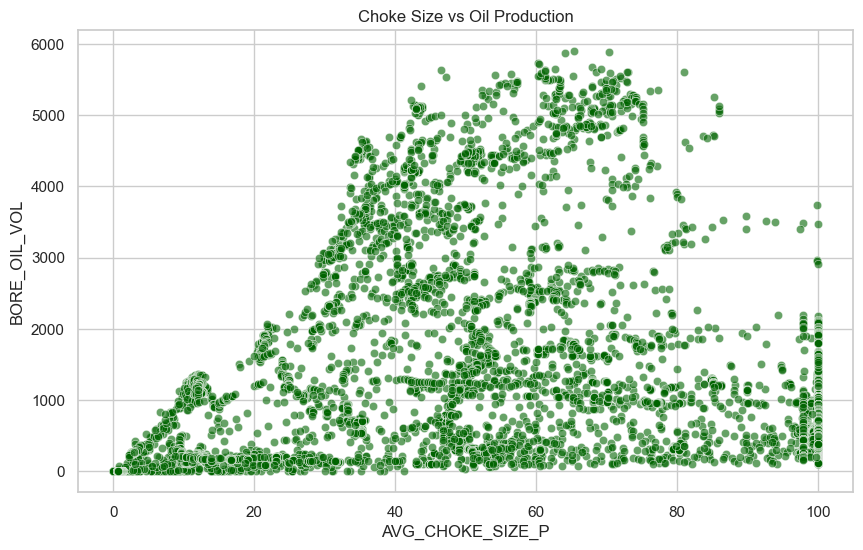

In [24]:
# ==========================================
# Choke Size vs Oil Production
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="AVG_CHOKE_SIZE_P",
    y="BORE_OIL_VOL",
    alpha=0.6,
    color="darkgreen"
)

plt.title("Choke Size vs Oil Production")

plt.show()

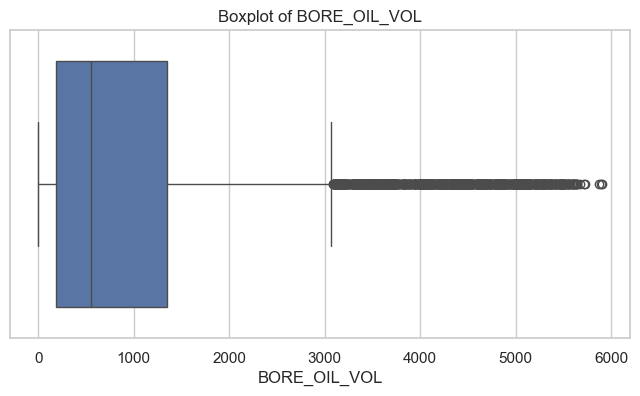

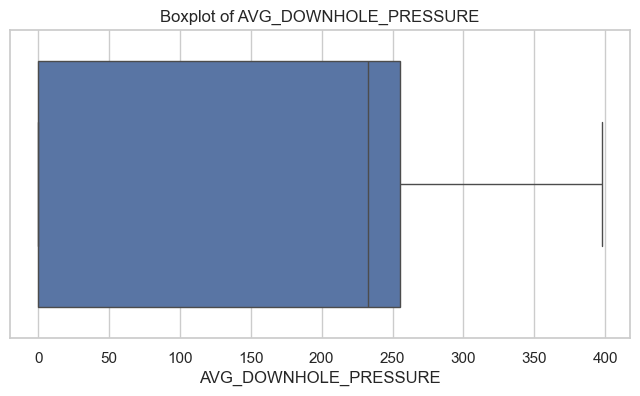

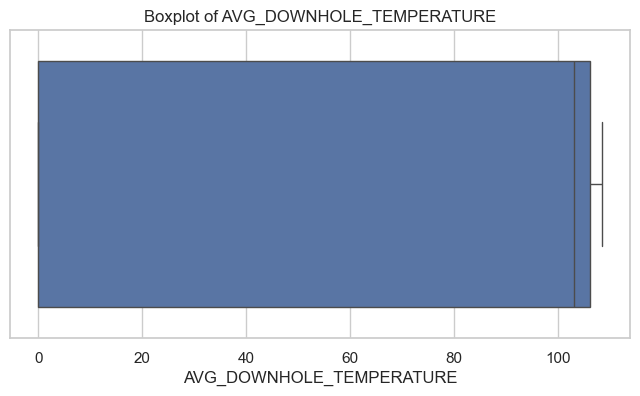

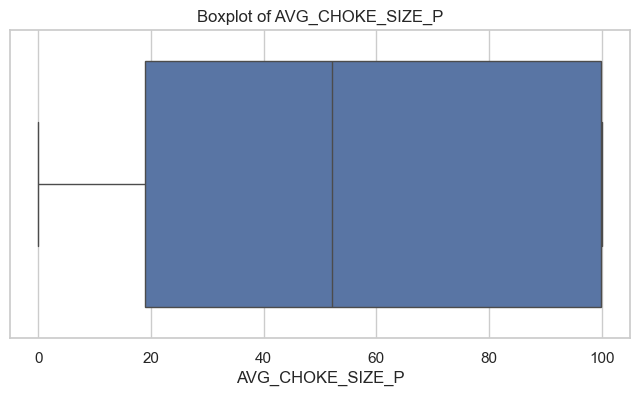

In [25]:
# ==========================================
# Boxplots for Outlier Detection
# ==========================================

features = [
    "BORE_OIL_VOL",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_CHOKE_SIZE_P"
]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")

    plt.show()

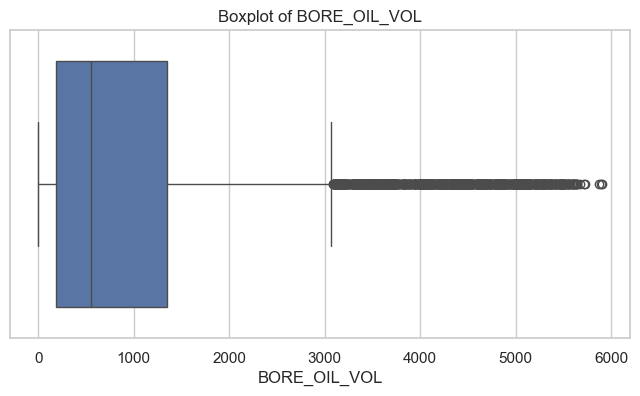

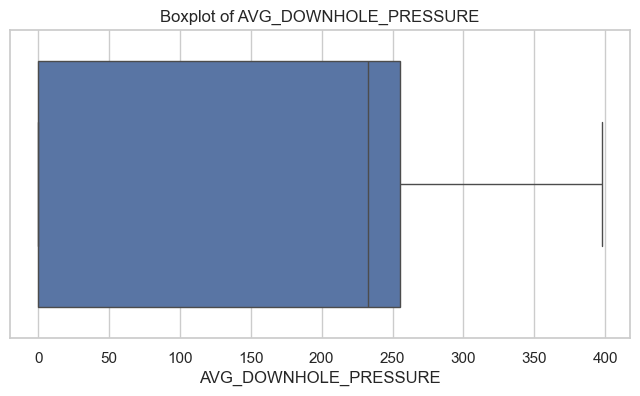

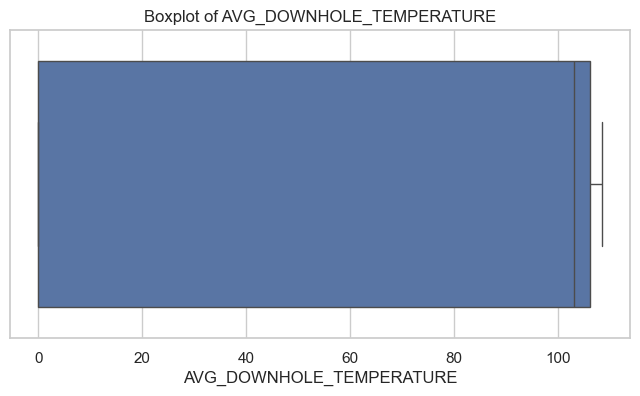

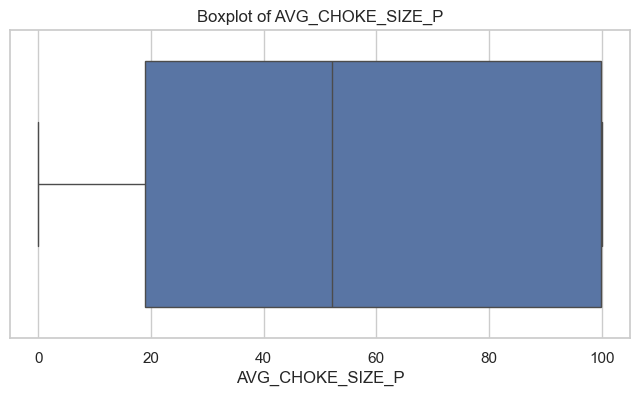

In [26]:
# ==========================================
# Boxplots for Outlier Detection
# ==========================================

features = [
    "BORE_OIL_VOL",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_CHOKE_SIZE_P"
]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")

    plt.show()

In [27]:
# ==========================================
# Create a Working Copy of the Dataset
# ==========================================

df_clean = df.copy()

print("Working copy created successfully.")
print("Dataset Shape:", df_clean.shape)

Working copy created successfully.
Dataset Shape: (15634, 24)


In [28]:
# ==========================================
# Missing Values Summary
# ==========================================

missing = df_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(df_clean)) * 100, 2)
})

missing_df

,Missing Values,Percentage (%)
BORE_WI_VOL,9928,63.50
AVG_ANNULUS_PRESS,7744,49.53
AVG_CHOKE_SIZE_P,6715,42.95
AVG_DOWNHOLE_PRESSURE,6654,42.56
AVG_DOWNHOLE_TEMPERATURE,6654,42.56
AVG_DP_TUBING,6654,42.56
AVG_WHT_P,6488,41.50
AVG_WHP_P,6479,41.44
AVG_CHOKE_UOM,6473,41.40
BORE_OIL_VOL,6473,41.40


In [29]:
# ==========================================
# Remove Columns with Excessive Missing Values
# ==========================================

threshold = 0.5 * len(df_clean)

columns_to_drop = df_clean.columns[df_clean.isnull().sum() > threshold]

print("Columns Removed:")
print(columns_to_drop.tolist())

df_clean.drop(columns=columns_to_drop, inplace=True)

print("\nRemaining Columns:", len(df_clean.columns))

Columns Removed:
['BORE_WI_VOL']

Remaining Columns: 23


In [30]:
# ==========================================
# Fill Missing Numerical Values
# ==========================================

numerical_columns = df_clean.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df_clean[column].fillna(df_clean[column].median(), inplace=True)

print("Missing numerical values handled.")

Missing numerical values handled.


In [31]:
# ==========================================
# Fill Missing Categorical Values
# ==========================================

categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    df_clean[column].fillna(df_clean[column].mode()[0], inplace=True)

print("Missing categorical values handled.")

Missing categorical values handled.


In [32]:
# ==========================================
# Verify Missing Values
# ==========================================

print("Remaining Missing Values")

df_clean.isnull().sum().sort_values(ascending=False).head(10)

Remaining Missing Values


AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_DP_TUBING               6654
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_WHT_P                   6488
AVG_WHP_P                   6479
AVG_CHOKE_UOM               6473
BORE_WAT_VOL                6473
BORE_GAS_VOL                6473
dtype: int64

In [33]:
# ==========================================
# Remove Duplicate Records
# ==========================================

before = df_clean.shape[0]

df_clean.drop_duplicates(inplace=True)

after = df_clean.shape[0]

print(f"Rows Before : {before}")
print(f"Rows After  : {after}")
print(f"Duplicates Removed : {before-after}")

Rows Before : 15634
Rows After  : 15634
Duplicates Removed : 0


In [34]:
# ==========================================
# Sort by Date
# ==========================================

df_clean.sort_values(
    by="DATEPRD",
    inplace=True
)

df_clean.reset_index(
    drop=True,
    inplace=True
)

print("Dataset sorted successfully.")

Dataset sorted successfully.


In [35]:
# ==========================================
# Feature Engineering
# Date Features
# ==========================================

df_clean["YEAR"] = df_clean["DATEPRD"].dt.year
df_clean["MONTH"] = df_clean["DATEPRD"].dt.month
df_clean["DAY"] = df_clean["DATEPRD"].dt.day
df_clean["DAY_OF_WEEK"] = df_clean["DATEPRD"].dt.dayofweek

print("Date features created successfully.")

Date features created successfully.


In [36]:
# ==========================================
# Select Model Features
# ==========================================

selected_features = [

    "ON_STREAM_HRS",

    "AVG_DOWNHOLE_PRESSURE",

    "AVG_DOWNHOLE_TEMPERATURE",

    "AVG_DP_TUBING",

    "AVG_ANNULUS_PRESS",

    "AVG_WHP_P",

    "AVG_WHT_P",

    "AVG_CHOKE_SIZE_P",

    "DP_CHOKE_SIZE",

    "YEAR",

    "MONTH",

    "DAY",

    "DAY_OF_WEEK"

]

target = "BORE_OIL_VOL"

print("Number of Features:", len(selected_features))

Number of Features: 13


In [37]:
# ==========================================
# Prepare Feature Matrix and Target
# ==========================================

X = df_clean[selected_features]

y = df_clean[target]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (15634, 13)
Target Shape : (15634,)


In [38]:
# ==========================================
# Final Dataset Information
# ==========================================

print("Feature Columns")

display(X.head())

print("\nTarget")

display(y.head())

Feature Columns


,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_WHP_P,AVG_WHT_P,AVG_CHOKE_SIZE_P,DP_CHOKE_SIZE,YEAR,MONTH,DAY,DAY_OF_WEEK
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,9,1,5
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,9,1,5
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,9,2,6
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,9,2,6
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,9,3,0



Target


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: BORE_OIL_VOL, dtype: float64

# Machine Learning Pipeline

## Data Cleaning and Feature Engineering

Before training the Random Forest Regressor, the dataset is preprocessed to improve data quality and model performance. This stage includes handling missing values, removing duplicate records, engineering new features from the date column, and selecting the most relevant variables for production forecasting.

The objective is to prepare a clean and informative feature set that enables the model to accurately predict daily oil production.

In [39]:
# Replace infinities with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing feature values
X = X.fillna(X.median(numeric_only=True))

# Fill missing target values
y = y.fillna(y.median())

In [40]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*50)
print("Train-Test Split Completed")
print("="*50)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Number of Features : {X_train.shape[1]}")

Train-Test Split Completed
Training Samples : 12507
Testing Samples  : 3127
Number of Features : 13


In [41]:
# ==========================================
# Train Random Forest Regressor
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [42]:
# ==========================================
# Predict on Test Set
# ==========================================

y_pred = rf_model.predict(X_test)

print("Prediction Completed.")

Prediction Completed.


In [43]:
# ==========================================
# Model Evaluation
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("="*50)
print("Random Forest Performance")
print("="*50)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R² Score : {r2:.4f}")

Random Forest Performance
MAE  : 32.391
MSE  : 10090.305
RMSE : 100.451
R² Score : 0.9905


In [44]:
# ==========================================
# Evaluation Summary
# ==========================================

results = pd.DataFrame({
    "Metric":[
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error",
        "R² Score"
    ],
    "Value":[
        mae,
        mse,
        rmse,
        r2
    ]
})

results

,Metric,Value
0,Mean Absolute Error,32.390845
1,Mean Squared Error,10090.305208
2,Root Mean Squared Error,100.450511
3,R² Score,0.990501


In [45]:
# ==========================================
# Evaluation Summary
# ==========================================

results = pd.DataFrame({
    "Metric":[
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error",
        "R² Score"
    ],
    "Value":[
        mae,
        mse,
        rmse,
        r2
    ]
})

results

,Metric,Value
0,Mean Absolute Error,32.390845
1,Mean Squared Error,10090.305208
2,Root Mean Squared Error,100.450511
3,R² Score,0.990501


In [46]:
# ==========================================
# Actual vs Predicted
# ==========================================

comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison.head(20)

,Actual,Predicted
15243,125.94,384.402468
9097,557.55,557.498347
5729,1864.94,1872.462360
8957,557.55,557.495671
10345,198.40,194.442701
12320,557.55,557.496368
8581,557.55,557.495671
5828,760.83,804.810467
4010,0.00,0.000000
4280,1581.71,1996.924618


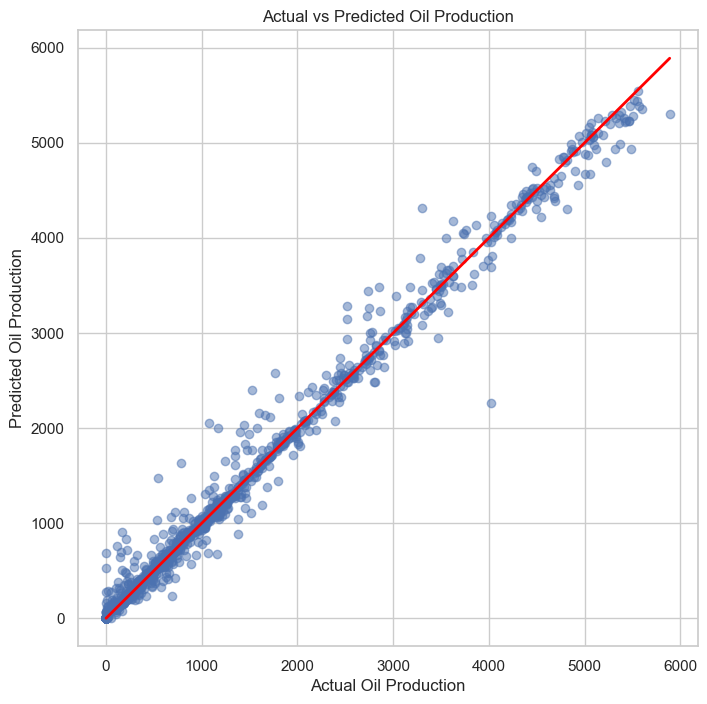

In [47]:
# ==========================================
# Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Oil Production")

plt.ylabel("Predicted Oil Production")

plt.title("Actual vs Predicted Oil Production")

plt.grid(True)

plt.show()

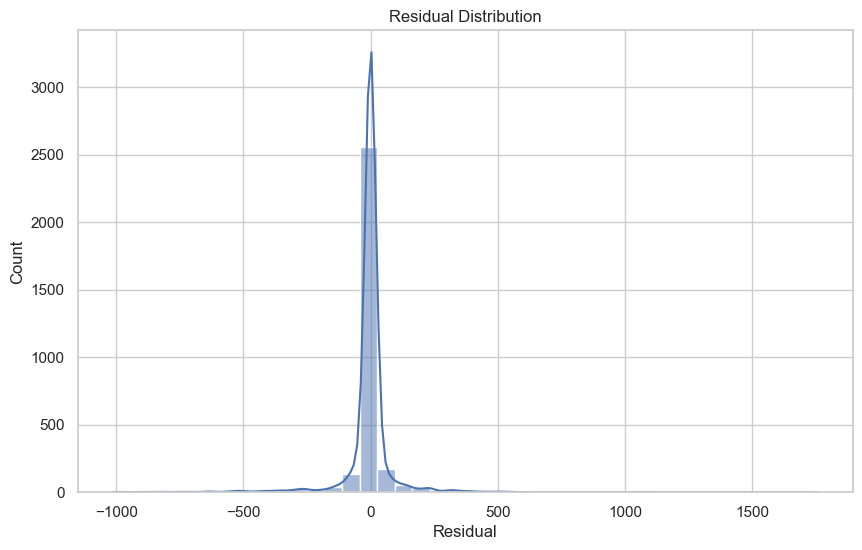

In [48]:
# ==========================================
# Residual Analysis
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

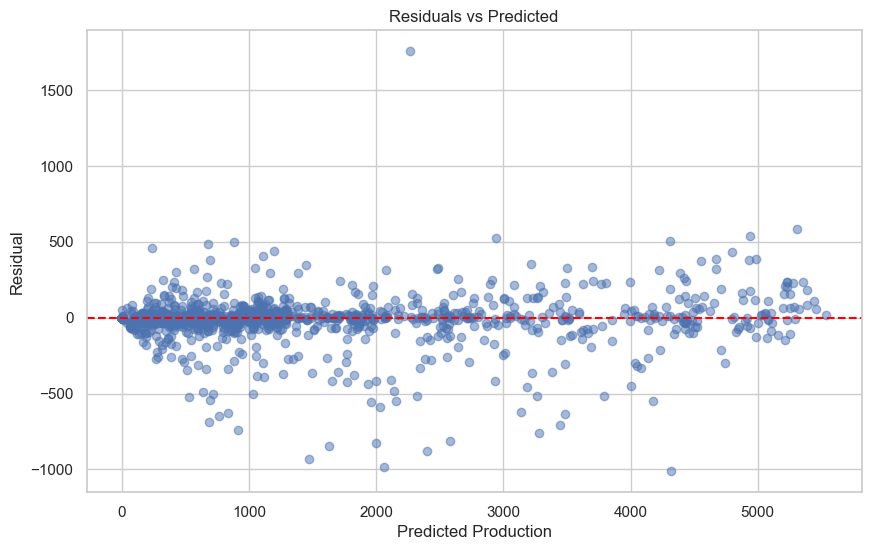

In [49]:
# ==========================================
# Residual Scatter Plot
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Production")

plt.ylabel("Residual")

plt.title("Residuals vs Predicted")

plt.show()

In [50]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature":selected_features,
    "Importance":rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,AVG_WHP_P,0.376487
9,YEAR,0.363543
6,AVG_WHT_P,0.072762
0,ON_STREAM_HRS,0.054330
7,AVG_CHOKE_SIZE_P,0.053646
4,AVG_ANNULUS_PRESS,0.034017
3,AVG_DP_TUBING,0.012705
1,AVG_DOWNHOLE_PRESSURE,0.010684
2,AVG_DOWNHOLE_TEMPERATURE,0.010111
10,MONTH,0.006294


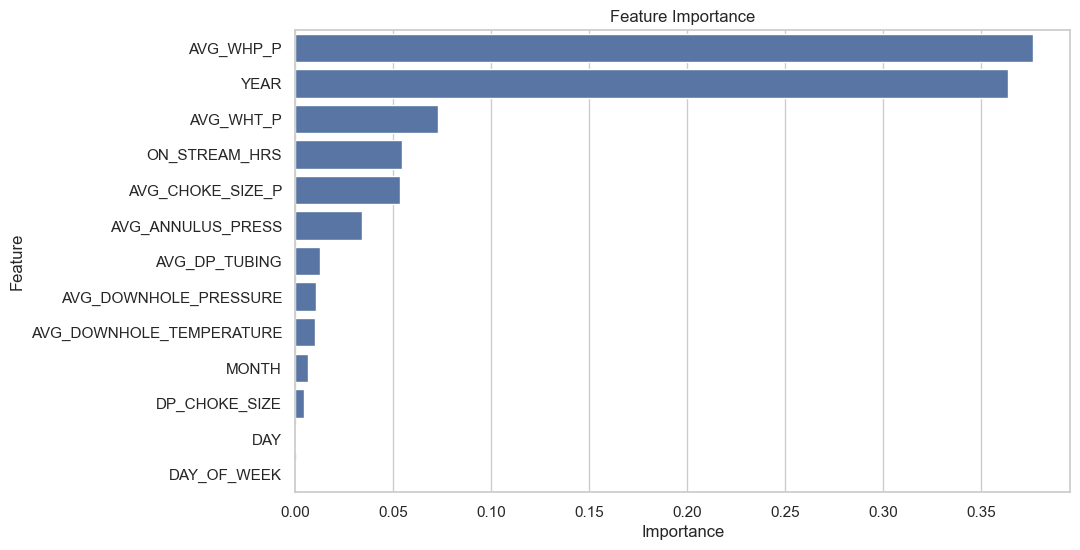

In [51]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [52]:
# ==========================================
# Save Trained Model
# ==========================================

joblib.dump(
    rf_model,
    "production_model.pkl"
)

joblib.dump(
    selected_features,
    "production_features.pkl"
)

print("Model Saved Successfully.")

Model Saved Successfully.


In [53]:
# ==========================================
# Final Remarks
# ==========================================

print("="*60)
print("Production Forecasting Pipeline Completed")
print("="*60)

print(f"Model : Random Forest Regressor")
print(f"Features Used : {len(selected_features)}")
print(f"R² Score : {r2:.4f}")
print(f"RMSE : {rmse:.3f}")

print("\nArtifacts Generated")

print("production_model.pkl")
print("production_features.pkl")

Production Forecasting Pipeline Completed
Model : Random Forest Regressor
Features Used : 13
R² Score : 0.9905
RMSE : 100.451

Artifacts Generated
production_model.pkl
production_features.pkl


# Advanced Model Analysis and Explainability

This section provides a deeper evaluation of the Random Forest model beyond traditional regression metrics. The analyses include production trend comparisons, error distribution, learning curves, feature importance, explainability using SHAP values, partial dependence plots, and well-wise prediction performance.

These analyses help understand model behavior, identify influential operational parameters, and assess the robustness of the production forecasting model.

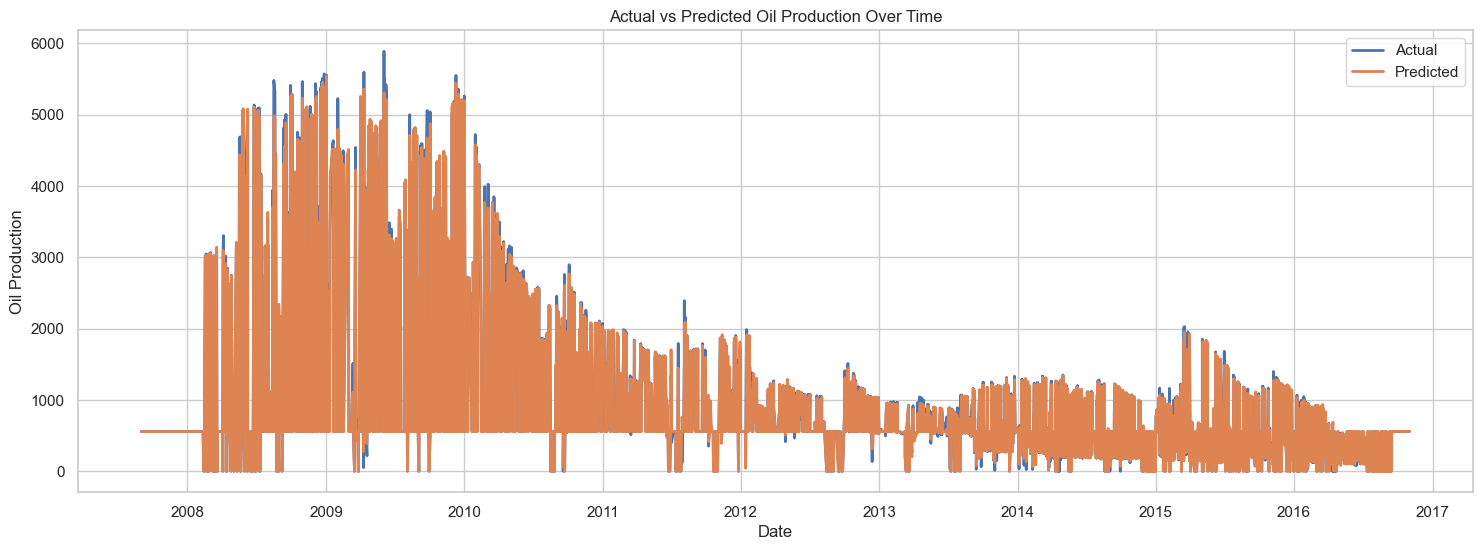

In [54]:
# ==========================================
# Predicted vs Actual Production Over Time
# ==========================================

comparison = pd.DataFrame({
    "Date": df_clean.loc[y_test.index, "DATEPRD"],
    "Actual": y_test,
    "Predicted": y_pred
})

comparison = comparison.sort_values("Date")

plt.figure(figsize=(18,6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Oil Production Over Time")

plt.xlabel("Date")

plt.ylabel("Oil Production")

plt.legend()

plt.grid(True)

plt.show()

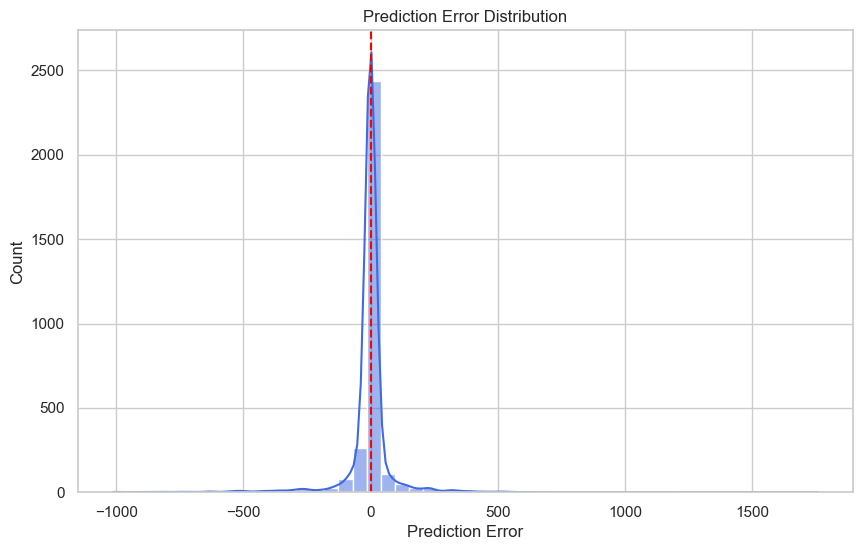

In [55]:
# ==========================================
# Prediction Error Distribution
# ==========================================

errors = y_test - y_pred

plt.figure(figsize=(10,6))

sns.histplot(
    errors,
    bins=50,
    kde=True,
    color="royalblue"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

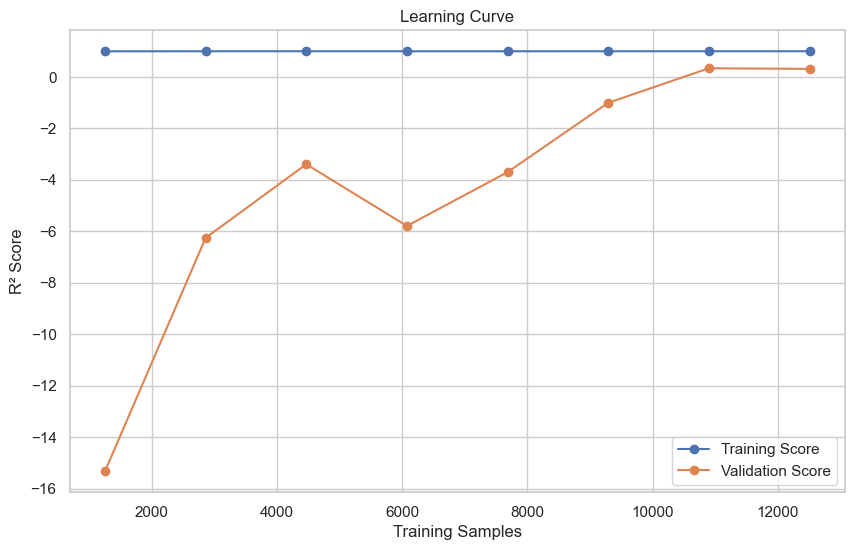

In [56]:
# ==========================================
# Learning Curve
# ==========================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=rf_model,
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label="Validation Score"
)

plt.title("Learning Curve")

plt.xlabel("Training Samples")

plt.ylabel("R² Score")

plt.legend()

plt.grid(True)

plt.show()

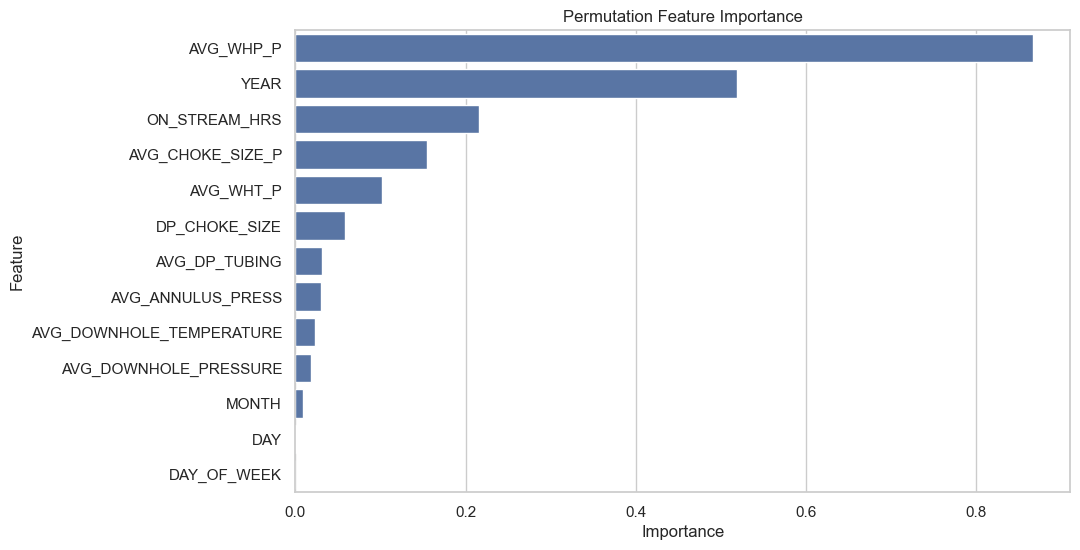

In [57]:
# ==========================================
# Permutation Feature Importance
# ==========================================

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.show()

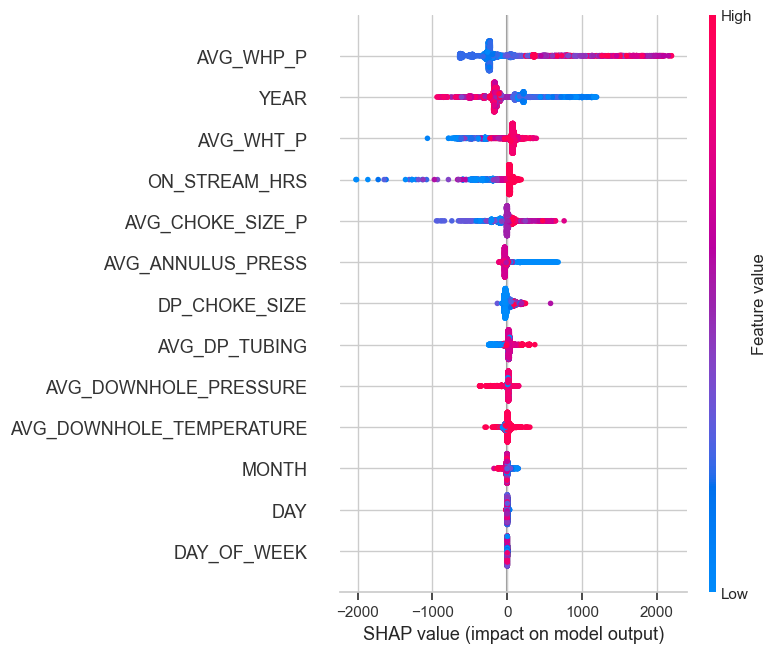

In [66]:
# ==========================================
# SHAP Explainability
# ==========================================

import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

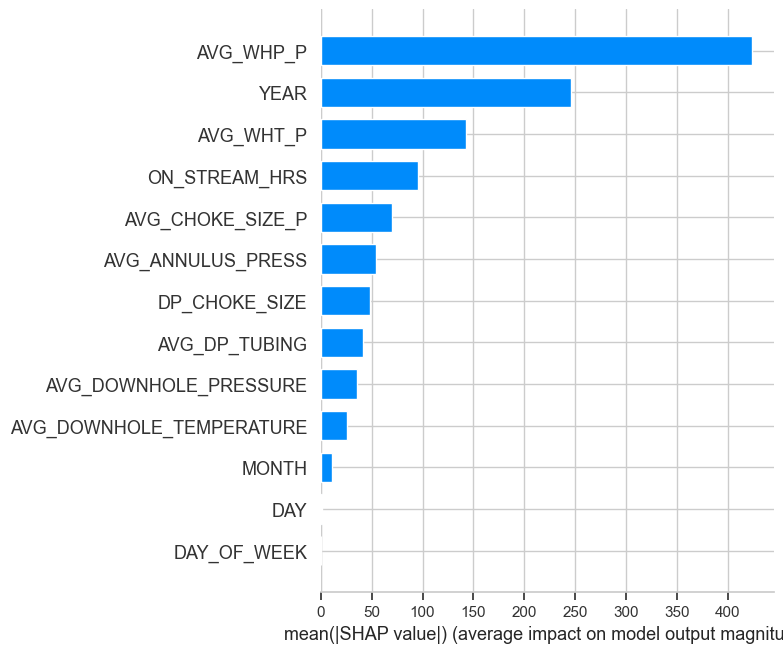

In [59]:
# ==========================================
# SHAP Bar Plot
# ==========================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

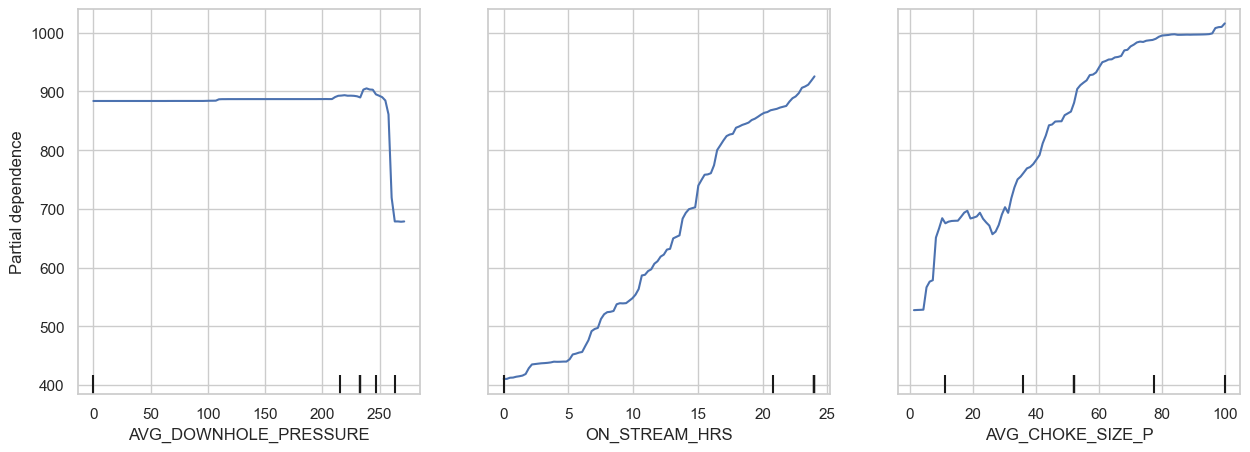

In [60]:
# ==========================================
# Partial Dependence Plot
# ==========================================

from sklearn.inspection import PartialDependenceDisplay

important_features = [
    "AVG_DOWNHOLE_PRESSURE",
    "ON_STREAM_HRS",
    "AVG_CHOKE_SIZE_P"
]

fig, ax = plt.subplots(figsize=(15,5))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    important_features,
    ax=ax
)

plt.show()

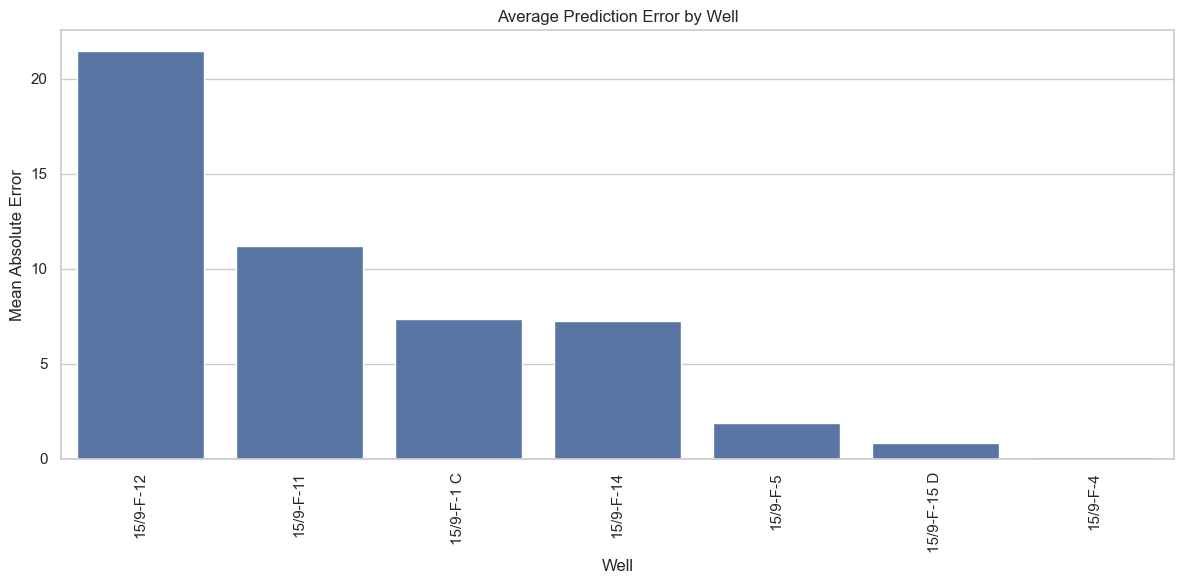

In [61]:
# ==========================================
# Well-wise Prediction Performance
# ==========================================

well_df = df_clean.loc[y_test.index, [
    "NPD_WELL_BORE_NAME",
    "DATEPRD"
]].copy()

well_df["Actual"] = y_test.values
well_df["Predicted"] = y_pred

well_performance = (
    well_df
    .groupby("NPD_WELL_BORE_NAME")
    .agg({
        "Actual": "mean",
        "Predicted": "mean"
    })
)

well_performance["Error"] = (
    well_performance["Actual"] -
    well_performance["Predicted"]
).abs()

well_performance = well_performance.sort_values(
    by="Error",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=well_performance.reset_index(),
    x="NPD_WELL_BORE_NAME",
    y="Error"
)

plt.xticks(rotation=90)

plt.title("Average Prediction Error by Well")

plt.xlabel("Well")

plt.ylabel("Mean Absolute Error")

plt.tight_layout()

plt.show()

In [62]:
# ==========================================
# Top Performing Wells
# ==========================================

well_performance.head(10)

,Actual,Predicted,Error
NPD_WELL_BORE_NAME,,,
15/9-F-12,1439.485710,1460.963505,21.477795
15/9-F-11,982.555407,971.371619,11.183787
15/9-F-1 C,214.055492,221.430492,7.375000
15/9-F-14,1284.132867,1291.395660,7.262793
15/9-F-5,542.467832,544.375340,1.907508
15/9-F-15 D,152.000676,151.160162,0.840514
15/9-F-4,557.550000,557.461459,0.088541


In [63]:
# ==========================================
# Wells with Highest Prediction Error
# ==========================================

well_performance.tail(10)

,Actual,Predicted,Error
NPD_WELL_BORE_NAME,,,
15/9-F-12,1439.485710,1460.963505,21.477795
15/9-F-11,982.555407,971.371619,11.183787
15/9-F-1 C,214.055492,221.430492,7.375000
15/9-F-14,1284.132867,1291.395660,7.262793
15/9-F-5,542.467832,544.375340,1.907508
15/9-F-15 D,152.000676,151.160162,0.840514
15/9-F-4,557.550000,557.461459,0.088541


In [64]:
forecast_results = df_clean.loc[y_test.index].copy()

forecast_results["Actual Production"] = y_test.values

forecast_results["Predicted Production"] = y_pred

forecast_results["Forecast Error"] = (
    forecast_results["Actual Production"] -
    forecast_results["Predicted Production"]
)

forecast_results["Absolute Error"] = (
    forecast_results["Forecast Error"].abs()
)

forecast_results["Percentage Error"] = (
    forecast_results["Absolute Error"] /
    forecast_results["Actual Production"] * 100
)

forecast_results.to_csv(
    "production_forecast_results.csv",
    index=False
)

print("Production Forecast Results Saved Successfully.")

Production Forecast Results Saved Successfully.


In [65]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)